# Question 1: Is there a noticeable similarity between the  brain’s ventral visual stream and the model activations?
## Macaque ventral stream vs. Stable Diffusion

Kriegeskorte, Mur & Bandettini (2008), *Representational similarity analysis*, Front. Syst. Neurosci.
<https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full>

Data: TVSD (Papale et al.) -- THINGS images, 1024-channel normMUA, macaque V1/V4/IT.
<https://gin.g-node.org/paolo_papale/TVSD>

| Step | Content |
|---|---|
| 1 | Activity patterns per ROI |
| 2 | Brain RDMs, MDS of conditions, alternative distance measures, reliability |
| 3 | Model RDMs: diffusion timesteps, low-level controls, categorical |
| 4 | Brain vs. model RDM correlation |
| 5 | Permutation test, bootstrap CIs, model-vs-model comparison |
| 6 | Second-order RDM and MDS of the RDM landscape |


## 0 - Configuration

In [ ]:
MONKEY      = "monkeyF"
SPLIT       = "train"

# int caps the number of conditions; None = all
MAX_IMAGES  = 10

# extra trials requested, assuming some stimuli fail to load
OVERSAMPLE  = 1.3 


ROIS        = ["V1", "V4", "IT"]

ZSCORE_CHANNELS = True
BRAIN_DISTANCE  = "correlation"
RDM_COMPARE     = "spearman"
N_PERMUTATIONS  = 10000
N_BOOTSTRAPS    = 1000
RANDOM_SEED     = 0

NORMALIZED_TIMESTEPS = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
SD_BATCH_SIZE        = 4

import numpy as np
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr, rankdata
from sklearn.manifold import MDS

from diffusion_brain_alignment.data.things_monkey_ephys import (
    data_dir, area_channels, download, download_images,
    sample_trials, load_stimuli, load_brain_response,
)

from diffusion_brain_alignment.models.stable_diffusion import extract_features
import torch

/mnt/c/Users/Alina/Documents/github/nma/venvo/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [3]:
download(monkey=MONKEY)
download_images()
print((data_dir / MONKEY / "_logs" / "things_imgs.mat").exists(),
      (data_dir / MONKEY / "THINGS_normMUA.mat").exists())
print(area_channels[MONKEY])

True True
{'V1': (0, 512), 'IT': (512, 832), 'V4': (832, 1024)}


## Step 1 - Activity patterns

One row per image, one column per electrode, per ROI.

`load_stimuli` returns `None` for some trials, so trials are oversampled, filtered, then
trimmed to `MAX_IMAGES`. Channels are z-scored across conditions: correlation distance
normalizes each pattern, not each channel, and electrodes differ in gain.

In [4]:
def load_conditions(monkey, split, max_images, oversample, rois):
    n_req = int(np.ceil(max_images * oversample)) if max_images else None
    trials = (sample_trials(monkey=monkey, split=split, n_samples=n_req) if n_req
              else sample_trials(monkey=monkey, split=split))

    imgs_raw = load_stimuli(trials)
    names    = list(trials["image_names"])
    valid    = [i for i, im in enumerate(imgs_raw) if im is not None]
    if max_images:
        valid = valid[:max_images]

    resp = {roi: np.asarray(load_brain_response(trials, roi=roi))[valid] for roi in rois}
    return resp, [np.asarray(imgs_raw[i]) for i in valid], [names[i] for i in valid]


def clean_patterns(patterns):
    p = np.nan_to_num(np.asarray(patterns, dtype=np.float64))
    p = p[:, p.std(axis=0) > 0]
    if not ZSCORE_CHANNELS:
        return p
    sd = p.std(axis=0, keepdims=True); sd[sd == 0] = 1.0
    return (p - p.mean(axis=0, keepdims=True)) / sd


resp_by_roi, images, names = load_conditions(MONKEY, SPLIT, MAX_IMAGES, OVERSAMPLE, ROIS)
brain_patterns = {roi: clean_patterns(r) for roi, r in resp_by_roi.items()}
N = len(images)

print(f"N = {N}")
for roi, p in brain_patterns.items():
    print(f"  {roi}: {p.shape}")

/mnt/c/Users/Alina/Documents/github/nma/diffusion-brain-alignment/data/things/images_THINGS.zip
N = 10
  V1: (10, 512)
  V4: (10, 192)
  IT: (10, 320)


## Step 2 - Brain RDMs

Pairwise dissimilarity between activity patterns. Correlation distance (`1 - r`) is the
paper's default measure.

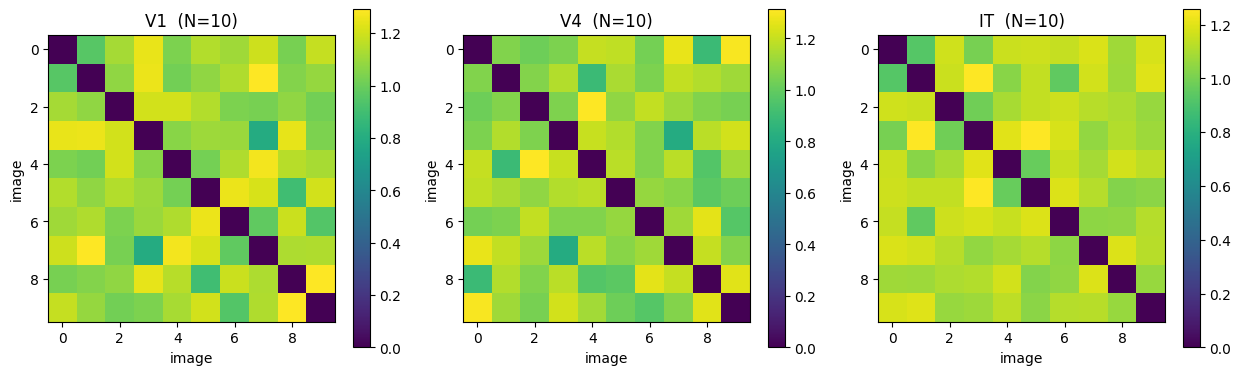

In [5]:
def compute_rdm(patterns, metric="correlation"):
    return squareform(pdist(np.asarray(patterns, dtype=np.float64), metric=metric))

def upper_tri(rdm):
    return rdm[np.triu_indices_from(rdm, k=1)]

brain_rdms = {roi: compute_rdm(p, BRAIN_DISTANCE) for roi, p in brain_patterns.items()}

fig, axes = plt.subplots(1, len(brain_rdms), figsize=(4.2 * len(brain_rdms), 3.8))
for ax, (roi, rdm) in zip(np.atleast_1d(axes), brain_rdms.items()):
    im = ax.imshow(rdm, cmap="viridis")
    ax.set_title(f"{roi}  (N={N})"); ax.set_xlabel("image"); ax.set_ylabel("image")
    plt.colorbar(im, ax=ax)
fig.tight_layout(); plt.show()

### Alternative dissimilarity measures

Correlation distance, Euclidean distance, and absolute difference of the regional-mean
response. The last reduces each condition to one number, so it is the RSA equivalent of
conventional activation-based analysis.

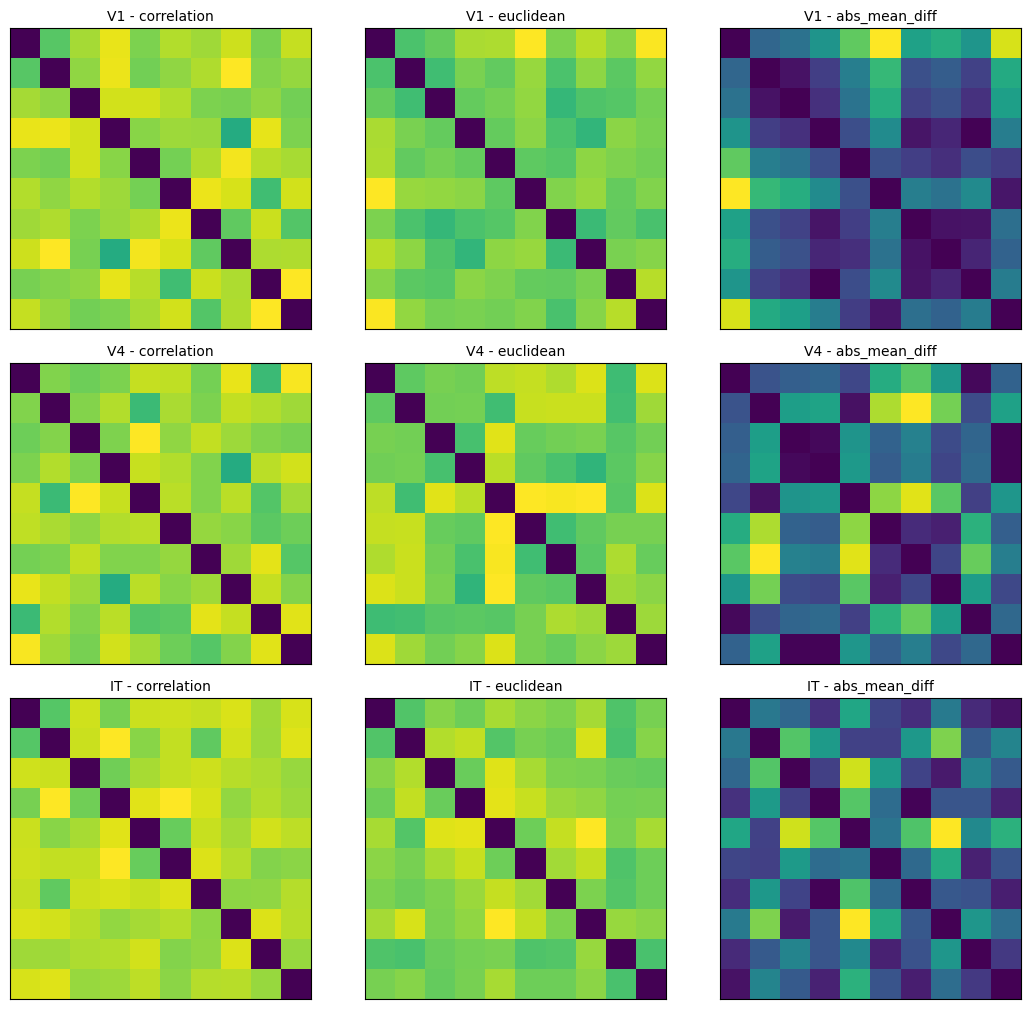

Agreement between measures (Spearman):
  V1: corr-eucl +0.571   corr-absmean -0.062
  V4: corr-eucl +0.552   corr-absmean +0.295
  IT: corr-eucl +0.662   corr-absmean +0.258


In [6]:
def rdm_absolute_mean_difference(patterns):
    m = np.asarray(patterns, dtype=np.float64).mean(axis=1)
    return np.abs(m[:, None] - m[None, :])

alt_rdms = {}
for roi, p in brain_patterns.items():
    alt_rdms[roi] = {
        "correlation": compute_rdm(p, "correlation"),
        "euclidean":   compute_rdm(p, "euclidean"),
        "abs_mean_diff": rdm_absolute_mean_difference(p),
    }

fig, axes = plt.subplots(len(ROIS), 3, figsize=(11, 3.4 * len(ROIS)))
axes = np.atleast_2d(axes)
for i, roi in enumerate(ROIS):
    for j, (mname, rdm) in enumerate(alt_rdms[roi].items()):
        axes[i, j].imshow(rdm, cmap="viridis")
        axes[i, j].set_title(f"{roi} - {mname}", fontsize=10)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
fig.tight_layout(); plt.show()

print("Agreement between measures (Spearman):")
for roi in ROIS:
    c, e, a = (alt_rdms[roi][k] for k in ("correlation", "euclidean", "abs_mean_diff"))
    print(f"  {roi}: corr-eucl {spearmanr(upper_tri(c), upper_tri(e)).correlation:+.3f}   "
          f"corr-absmean {spearmanr(upper_tri(c), upper_tri(a)).correlation:+.3f}")

## Step 3 - Model RDMs

Three families, matching the paper's Fig. 6: a complex computational model (the diffusion
U-Net), simple image-based models, and conceptual/categorical models.

### 3a - Diffusion model, one RDM per noise level

In [7]:
def as_pil(img):
    """ImageDataset -> transforms.Resize needs PIL; load_conditions gives ndarray."""
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    a = np.asarray(img)
    if a.dtype != np.uint8:
        a = (np.clip(a, 0, 1) * 255).astype(np.uint8) if a.max() <= 1.0 \
            else np.clip(a, 0, 255).astype(np.uint8)
    return Image.fromarray(a).convert("RGB")

images_pil = [as_pil(im) for im in images]

diffusion_rdms = {}
diffusion_acts = {}

for t_norm in NORMALIZED_TIMESTEPS:
    torch.manual_seed(0)
    acts = extract_features(images_pil, normalized_timestep=t_norm,
                            batch_size=SD_BATCH_SIZE)
    acts = np.asarray(acts.detach().cpu().numpy(), dtype=np.float64)
    assert acts.shape[0] == N, f"{acts.shape[0]} activations for {N} images"

    label = f"diffusion_t{int(t_norm * 1000)}"
    diffusion_acts[label] = acts
    diffusion_rdms[label] = compute_rdm(acts, "correlation")
    print(f"{label}: {acts.shape}")

diffusion_t0: (10, 1280)
diffusion_t100: (10, 1280)
diffusion_t300: (10, 1280)
diffusion_t500: (10, 1280)
diffusion_t700: (10, 1280)
diffusion_t900: (10, 1280)


### 3b - Simple image-based models

V1 tracks luminance, contrast and spatial frequency. Without these controls, a diffusion-to-V1
correlation is equally consistent with both simply tracking image statistics.

In [8]:
def resize_stack(imgs, size=(128, 128)):
    out = []
    for im in imgs:
        a = np.asarray(im)
        if a.dtype != np.uint8:
            a = (np.clip(a, 0, 1) * 255).astype(np.uint8) if a.max() <= 1.0 \
                else np.clip(a, 0, 255).astype(np.uint8)
        out.append(np.asarray(Image.fromarray(a).convert("RGB").resize(size[::-1]),
                              dtype=np.float32) / 255.0)
    return np.stack(out)

IM = resize_stack(images)
G  = IM.mean(-1)

control_models = {
    "grayscale":  G.reshape(N, -1),
    "low_pass":   np.stack([gaussian_filter(x, 4) for x in G]).reshape(N, -1),
    "high_pass":  np.stack([x - gaussian_filter(x, 4) for x in G]).reshape(N, -1),
}
control_rdms = {k: compute_rdm(v, "correlation") for k, v in control_models.items()}
print(list(control_rdms))

['grayscale', 'low_pass', 'high_pass']


In [9]:

all_model_rdms = {**diffusion_rdms, **control_rdms}
print(f"{len(all_model_rdms)} model RDMs:", list(all_model_rdms))

9 model RDMs: ['diffusion_t0', 'diffusion_t100', 'diffusion_t300', 'diffusion_t500', 'diffusion_t700', 'diffusion_t900', 'grayscale', 'low_pass', 'high_pass']


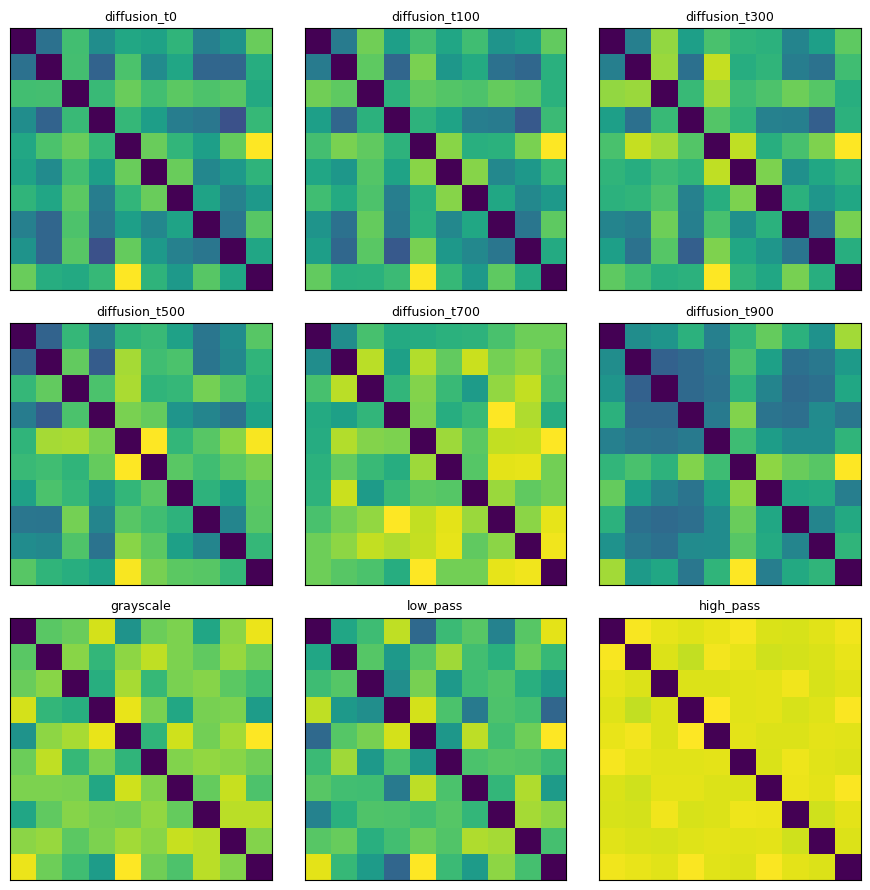

In [10]:
n_show = len(all_model_rdms)
ncol = 3
nrow = int(np.ceil(n_show / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 3.0 * nrow))
for ax, (name, rdm) in zip(np.atleast_1d(axes).ravel(), all_model_rdms.items()):
    ax.imshow(rdm, cmap="viridis"); ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
for ax in np.atleast_1d(axes).ravel()[n_show:]:
    ax.axis("off")
fig.tight_layout(); plt.show()

## Step 4 - Brain vs. model RDM correlation

Spearman on the upper triangles. Rank correlation assumes only a monotonic relationship
between the two dissimilarity measures.

In [11]:
def compare_rdms(a, b, method=RDM_COMPARE):
    x, y = upper_tri(a), upper_tri(b)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if x.std() == 0 or y.std() == 0:
        return np.nan
    return spearmanr(x, y).correlation if method == "spearman" else np.corrcoef(x, y)[0, 1]

fit_matrix = pd.DataFrame(
    {roi: {m: compare_rdms(brdm, mrdm) for m, mrdm in all_model_rdms.items()}
     for roi, brdm in brain_rdms.items()})
display(fit_matrix.style.background_gradient(cmap="RdBu_r", axis=None).format("{:+.3f}"))

,V1,V4,IT
diffusion_t0,-0.047,-0.023,+0.047
diffusion_t100,-0.064,-0.072,+0.024
diffusion_t300,-0.067,-0.030,+0.069
diffusion_t500,-0.086,-0.105,-0.042
diffusion_t700,-0.020,-0.158,-0.274
diffusion_t900,+0.199,+0.033,-0.021
grayscale,+0.163,+0.038,+0.044
low_pass,+0.124,-0.002,+0.065
high_pass,-0.424,+0.044,+0.018


## Step 5 - Randomization tests

RDM cells are not independent: each condition contributes to `N-1` of them, so a standard
correlation p-value is invalid. Two procedures:

- **Permutation** -- relabel conditions (reorder rows and columns of one RDM by the same
  permutation), recompute, repeat. Gives the null distribution.
- **Bootstrap** -- resample conditions with replacement for CIs. Duplicated conditions create
  artefactual off-diagonal zeros, which are excluded.

In [12]:
def permutation_test(brdm, mrdm, n_perm, rng):
    obs = compare_rdms(brdm, mrdm)
    n = brdm.shape[0]
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = rng.permutation(n)
        null[i] = compare_rdms(brdm[np.ix_(p, p)], mrdm)
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

def bootstrap_indices(n, n_boot, rng):
    return [rng.choice(n, size=n, replace=True) for _ in range(n_boot)]

def bootstrap_fit(brdm, mrdm, boot_idx):
    n = brdm.shape[0]
    iu = np.triu_indices(n, k=1)
    vals = []
    for idx in boot_idx:
        keep = idx[iu[0]] != idx[iu[1]]
        a = brdm[np.ix_(idx, idx)][iu][keep]
        b = mrdm[np.ix_(idx, idx)][iu][keep]
        if RDM_COMPARE == "spearman":
            a, b = rankdata(a), rankdata(b)
        vals.append(np.corrcoef(a, b)[0, 1])
    return np.array(vals)

boot_idx = bootstrap_indices(N, N_BOOTSTRAPS, rng)
boot_dist = {}
rows = []
for roi, brdm in brain_rdms.items():
    for m, mrdm in all_model_rdms.items():
        obs, p = permutation_test(brdm, mrdm, N_PERMUTATIONS, rng)
        b = bootstrap_fit(brdm, mrdm, boot_idx)
        boot_dist[(roi, m)] = b
        lo, hi = np.nanpercentile(b, [2.5, 97.5])
        rows.append(dict(roi=roi, model=m, r=obs, p=p, ci_lo=lo, ci_hi=hi))

stats = pd.DataFrame(rows)
stats["p_fdr"] = (stats["p"] * len(stats) / stats["p"].rank(method="first")).clip(upper=1.0)
display(stats.sort_values(["roi", "r"], ascending=[True, False])
             .style.format({"r": "{:+.3f}", "p": "{:.4f}", "p_fdr": "{:.4f}",
                            "ci_lo": "{:+.3f}", "ci_hi": "{:+.3f}"}))

,roi,model,r,p,ci_lo,ci_hi,p_fdr
20,IT,diffusion_t300,+0.069,0.2752,-0.409,+0.623,1.0000
25,IT,low_pass,+0.065,0.3364,-0.359,+0.520,1.0000
18,IT,diffusion_t0,+0.047,0.3240,-0.453,+0.607,1.0000
24,IT,grayscale,+0.044,0.3891,-0.370,+0.508,1.0000
19,IT,diffusion_t100,+0.024,0.4150,-0.452,+0.587,1.0000
26,IT,high_pass,+0.018,0.4591,-0.511,+0.607,1.0000
23,IT,diffusion_t900,-0.021,0.5839,-0.443,+0.383,0.9854
21,IT,diffusion_t500,-0.042,0.6332,-0.559,+0.446,0.9499
22,IT,diffusion_t700,-0.274,0.9932,-0.723,+0.255,1.0000
5,V1,diffusion_t900,+0.199,0.0245,-0.266,+0.693,0.6614


### 5a - Model-vs-model comparison

Whether the best-fitting model beats each competitor is tested on the *difference* of fits
across the same bootstrap resamples, which keeps the comparison paired.

In [13]:
comparisons = []
for roi in brain_rdms:
    s = stats[stats.roi == roi]
    best = s.loc[s["r"].idxmax(), "model"]
    for m in all_model_rdms:
        if m == best:
            continue
        d = boot_dist[(roi, best)] - boot_dist[(roi, m)]
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        comparisons.append(dict(roi=roi, best=best, other=m, delta=np.nanmean(d),
                                ci_lo=lo, ci_hi=hi,
                                p_two_sided=2 * min(np.nanmean(d <= 0), np.nanmean(d >= 0))))

comp = pd.DataFrame(comparisons)
display(comp.style.format({"delta": "{:+.3f}", "ci_lo": "{:+.3f}",
                           "ci_hi": "{:+.3f}", "p_two_sided": "{:.4f}"}))

,roi,best,other,delta,ci_lo,ci_hi,p_two_sided
0,V1,diffusion_t900,diffusion_t0,+0.238,-0.375,+0.729,0.3100
1,V1,diffusion_t900,diffusion_t100,+0.263,-0.309,+0.740,0.2520
2,V1,diffusion_t900,diffusion_t300,+0.258,-0.336,+0.749,0.2560
3,V1,diffusion_t900,diffusion_t500,+0.309,-0.242,+0.838,0.2000
4,V1,diffusion_t900,diffusion_t700,+0.248,-0.293,+0.878,0.3500
5,V1,diffusion_t900,grayscale,+0.062,-0.443,+0.536,0.7180
6,V1,diffusion_t900,low_pass,+0.100,-0.446,+0.599,0.6460
7,V1,diffusion_t900,high_pass,+0.639,+0.024,+1.255,0.0380
8,V4,high_pass,diffusion_t0,+0.020,-0.529,+0.473,0.8380
9,V4,high_pass,diffusion_t100,+0.070,-0.441,+0.477,0.6440


## Step 6 - Second-order RDM and MDS

Every RDM becomes one entity; the dissimilarity between two RDMs is `1 - their correlation`.

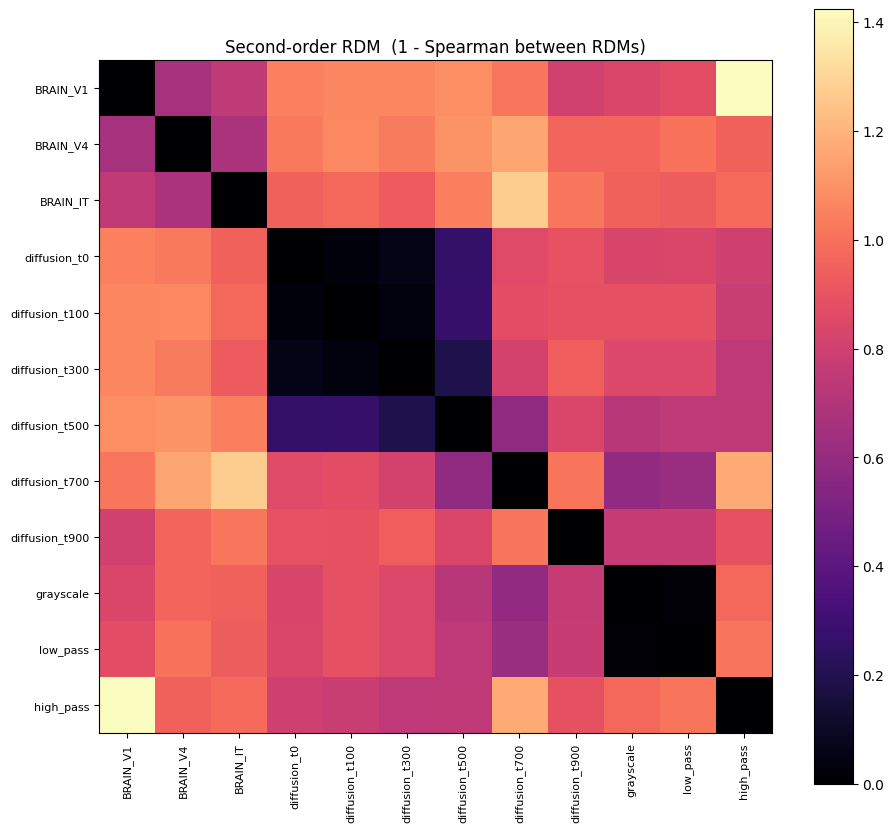

In [14]:
landscape = {**{f"BRAIN_{r}": v for r, v in brain_rdms.items()}, **all_model_rdms}
keys = list(landscape)
K = len(keys)

second_order = np.zeros((K, K))
for i in range(K):
    for j in range(i + 1, K):
        d = 1 - compare_rdms(landscape[keys[i]], landscape[keys[j]], "spearman")
        second_order[i, j] = second_order[j, i] = d

fig, ax = plt.subplots(figsize=(0.55 * K + 3, 0.55 * K + 2))
im = ax.imshow(second_order, cmap="magma")
ax.set_xticks(range(K)); ax.set_xticklabels(keys, rotation=90, fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels(keys, fontsize=8)
ax.set_title("Second-order RDM  (1 - Spearman between RDMs)")
plt.colorbar(im, ax=ax); fig.tight_layout(); plt.show()